# Buena Muerte Social Club

:::note
This is the companion notebook to the article *Buena Muerte Social Club*, submitted to [FUN 2026](https://fun2026.limos.fr/). It is NOT intended to be self-contained. Please refer to the paper for context and explanations.
:::

## Preliminaries

### Basic Blood Types

First, we define the different blood types. In addition to the $2^3$ main types depending on the presence of $A$, $B$, and $Rhesus$ markers, we add a void type that will be use later to model non-ghoul humans.

An important property is *can_feed*, that tells if a vampire of given type can feed on a ghoul of other type.

In [1]:
import numpy as np 

class BloodType:
    A = ["", "A"]
    B = ["", "B"]
    R = ["-", "+"]

    def __init__(self, i, j, k):
        self.markers = np.array([i, j, k])
        self.x = False

    def __repr__(self):
        if self.x:
            return 'X'
        i, j, k = self.markers
        result = f"{self.A[i]}{self.B[j]}{self.R[k]}"
        if len(result) == 1:
            return f"O{result}"
        else:
            return result

    @property
    def sanitized_name(self):
        res = self.__repr__()
        return res.replace('-','m').replace('+','p')

    def can_feed_on(self, other):
        return np.all(other.markers <= self.markers)

    @classmethod
    def void(cls):
        res = cls(1, 1, 1)
        res.x = True
        return res

Let us compute all possible groups. We'll store them in a list, a class, and a dict for easy access.

In [2]:
class Groups:
    pass

groups = [BloodType(i, j, k) for i in range(2) for j in range(2) for k in range(2)]
g = Groups
for t in groups:
    setattr(g, t.sanitized_name, t)
groups_ = {str(g): g for g in groups}

groups

[O-, O+, B-, B+, A-, A+, AB-, AB+]

### Vampire/Ghoul Types

We now define Vampire/Ghoul types, which are defined by two blood types. The following properties are defined :
- *autarkic*: the vampire can feed on their ghoul.
- *compatible_with*: each vampire of two pairs can feed on the other one ghoul.
- *swinger*: a non plug-and-drink pair compatible with another non plug-and-drink pair.
- *helpless*: a non plug-and-drink pair that is only compatible with plug-and-drink-pairs.
- *three_compatible*: each vampire of three pairs can feed on a distinct available ghoul, in a cyclic fashion.

In [3]:
class VGType:
    def __init__(self, v, g):
        self.v = v
        self.g = g
        self.compatible_types = []

    def __repr__(self):
        return f"{self.v}/{self.g}"

    @property
    def category(self):
        if self.auto_compatible:
            return "autarkic"
        if all(c.auto_compatible for c in self.compatible_types):
            return "helpless"
        return "swinger"
    
    @property
    def auto_compatible(self):
        return self.v.can_feed_on(self.g)

    def compatible_with(self, other):
        return self.v.can_feed_on(other.g) and other.v.can_feed_on(self.g)

    def three_cycle(self, other1, other2):
        return self.v.can_feed_on(other1.g) and other1.v.can_feed_on(other2.g) and other2.v.can_feed_on(self.g)
    
    def three_compatible_with(self, other1, other2):
        return self.three_cycle(other1, other2) or self.three_cycle(other2, other1)

We now prepare all possible VG pairs and observe their repartition.

In [4]:
from collections import Counter
vgs = [VGType(v, g) for v in groups for g in groups]
for v1 in vgs:
    for v2 in vgs:
        if v1.compatible_with(v2):
            v1.compatible_types.append(v2)
vgs_ = {str(vg): i for i, vg in enumerate(vgs)}
Counter(vg.category for vg in vgs)

Counter({'autarkic': 27, 'helpless': 19, 'swinger': 18})

### Human types

We call *human* a potential ghoul not affiliated yet to any vampire. Humans can be modeled as a VG pair where the vampire is a placeholder, denoted $X$, compatible with everyone, e.g. *X/O+*

In [5]:
class Human(VGType):
    category = "human"
    def __init__(self, g):
        self.v = BloodType.void() # alway compatible
        self.g = g

In [6]:
humans = [Human(g) for g in groups]
humans

[X/O-, X/O+, X/B-, X/B+, X/A-, X/A+, X/AB-, X/AB+]

### Blood type distribution

For numeric computation, we need statistics on the blood type probabilities. We leverage Wikipedia to access recent data.

In [7]:
import requests
import re
from bs4 import BeautifulSoup as bs
from fake_useragent import UserAgent
ua = UserAgent()
soup = bs(requests.get("https://en.wikipedia.org/wiki/Blood_type_distribution_by_country", headers={'User-Agent': ua.random}).content)

table = soup('table')[1]('tr')
names = [s.text.strip().replace("−", "-") for s in table[0]('th')[2:]]
blood_type_by_country = dict()
for line in table[1:]:
    country = line.th.text.strip().split('[')[0]
    stats = {n: float(s.text.strip()[:-1]) if s.text[0].isdigit() else 0.0 for n, s in zip(names, line('td')[1:])}
    total = sum(stats.values())
    blood_type_by_country[country] = {k: v/total for k, v in stats.items()} 
    blood_type_by_country[country]['X'] = 1.0

In [8]:
blood_type_by_country['United States']

{'O+': 0.374,
 'A+': 0.35700000000000004,
 'B+': 0.085,
 'AB+': 0.034,
 'O-': 0.066,
 'A-': 0.063,
 'B-': 0.015,
 'AB-': 0.006,
 'X': 1.0}

In [9]:
blood_type_by_country['France']

{'O+': 0.365,
 'A+': 0.382,
 'B+': 0.077,
 'AB+': 0.025,
 'O-': 0.065,
 'A-': 0.068,
 'B-': 0.013999999999999999,
 'AB-': 0.004,
 'X': 1.0}

In [10]:
blood_type_by_country['World']

{'O+': 0.3878396121603878,
 'A+': 0.2757297242702757,
 'B+': 0.0818099181900818,
 'AB+': 0.0201999798000202,
 'O-': 0.1323098676901323,
 'A-': 0.0818099181900818,
 'B-': 0.0201999798000202,
 'AB-': 0.00010099989900010099,
 'X': 1.0}

Given a list of VG types and a country, issue normalized arrival rates.

In [11]:
def arrival_rates(vgs, country="United States"):
    probs = blood_type_by_country[country]
    res = [probs[str(vg.v)]*probs[str(vg.g)] for vg in vgs ]
    total = sum(res)
    return [r/total for r in res]

For the record, one can compute distribution per VG category:

In [12]:
from collections import defaultdict
shares = defaultdict(float)
rates = arrival_rates(vgs)
for i, vg in enumerate(vgs):
    shares[vg.category] += float(100*rates[i])
dict(shares)

{'autarkic': 56.6078, 'helpless': 28.1786, 'swinger': 15.2136}

## Instability study

We know that the base model is not stabilisable. Yet, we still can investigate through simulations the practical performance of robust matching algorithm in that settings.

Towards that goal, we write a function that converts a list of VG types into a matching problem.

In [13]:
import stochastic_matching as sm

def build_model(vgs, country="United States", self=True, relaxed=False, threesomes=False):
    edges = []
    n = len(vgs)
    for i, vg in enumerate(vgs):
        if relaxed or (self and vg.auto_compatible):
            edges.append([i])
        for j in range(i+1, n):
            if vg.compatible_with(vgs[j]):
                edges.append([i, j])
            if not threesomes:
                continue
            for k in range(j+1, n):
                if vg.three_compatible_with(vgs[j], vgs[k]):
                    if any(str(p.v)==str(p.g) for p in [vg, vgs[j], vgs[k]]):
                        continue
                    edges.append([i, j, k])
    incidence = np.zeros((n, len(edges)), dtype=int)
    for i, e in enumerate(edges):
        incidence[e, i] = 1
    model = sm.Model(incidence=incidence, names=[str(vg) for vg in vgs], 
                     rates=arrival_rates(vgs, country=country))
    model.cats = [vg.category for vg in vgs]
    model.edges = edges
    try:
        model.adjacency = sm.model.incidence_to_adjacency(model.incidence)
    except ValueError:
        pass
    return model

### Swingers-only

We first focus on the inter-dependent types, because it is smaller and makes sense from a selfish perspective.

In [14]:
swingers = [vg for vg in vgs if vg.category == 'swinger']
model = build_model(swingers)
model.show_graph()

Nice structure.

In [15]:
model.kernel

Kernels of a graph with 18 nodes and 24 edges.
Node dimension is 0.
Edge dimension is 6
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 0.17028994 -0.17028994 -0.07412584  0.07412584  0.         -0.17028994
  -0.12829445  0.12829445  0.          0.07412584  0.12829445  0.
  -0.32576712  0.19747267 -0.44229877  0.36817293  0.19747267 -0.19747267
   0.36817293 -0.36817293  0.12771746  0.04257249  0.04257249 -0.04257249]
 [ 0.04439801 -0.04439801 -0.26529933  0.26529933  0.         -0.04439801
  -0.33257364  0.33257364  0.          0.26529933  0.33257364  0.
  -0.38079546  0.04822182  0.0484483  -0.31374763  0.04822182 -0.04822182
  -0.31374763  0.31374763  0.03329851  0.0110995   0.0110995  -0.0110995 ]
 [ 0.35072029 -0.35072029  0.12045588 -0.12045588  0.         -0.35072029
  -0.113703    0.113703    0.         -0.12045588  0.113703    0.
   0.12788313 -0.24158613  0.12232013 -0.00186425 -0.24158613  0.24158613
  -0.00186425  0.00186425  0.51304022 -0.16231993 -0.16231993  0.1623

As predicted, it is not stabilizable.

In [16]:
model.stabilizable

False

In [17]:
def grouped_delay(simu):
    from collections import defaultdict
    import numpy as np
    wait = defaultdict(float)
    for i, cat in enumerate(simu.model.cats):
        wait[cat] += float(simu.avg_queues[i])
    return dict(wait)

In [18]:
base_params = {"simulator": "longest", "n_steps": 10**9, "max_queue": 100000, "seed": 42}

In [19]:
xp = sm.XP("Swingers", model=model, **base_params)
res = sm.evaluate(xp, [grouped_delay])
res

  0%|          | 0/1 [00:00<?, ?it/s]

{'Swingers': {'grouped_delay': {'swinger': 43048.157124944}}}

### Helpless-excluded

Exluding helpless types is harsh but leads to strong stability.

We first remove the self-loops to have a simple graph to display (it is only for display).

In [45]:
helpfuls = [vg for vg in vgs if vg.category != 'helpless']
model = build_model(helpfuls, self=False)

colors = {"autarkic": "#00FF00", "swinger": "#FF8888", "helpless": "#FF0000"}
physics = {
    "solver": "barnesHut",
    "barnesHut": {
      "gravitationalConstant": -15000,  
      "centralGravity": 0.25,           
      "springLength": 200,              
      "springConstant": 0.0015,         
      "damping": 0.095,                 
      "avoidOverlap": 0.12              
    },
    "maxVelocity": 15,
    "stabilization": {
      "iterations": 800,
      "updateInterval": 25
    }
  }
nodes_info = [{"color": {"background": colors[vg.category]}} for vg in helpfuls]
options = {"width": "1000px", "nodes": {"font": {"size": 60}}, "physics": physics}
model.show_graph(vis_options=options, nodes_info=nodes_info)

Back to the real thing.

In [21]:
model = build_model(helpfuls)
model.kernel

Kernels of a graph with 45 nodes and 317 edges.
Node dimension is 0.
Edge dimension is 272
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 1.85577352e-01  4.60120460e-02  7.29821545e-02 ...  4.78644736e-04
  -1.19916425e-03 -1.67780899e-03]
 [ 1.70012321e-01  2.91401361e-02  6.69110172e-02 ...  2.85079976e-03
   9.21133624e-04 -1.92966614e-03]
 [ 1.51967077e-01  2.44349889e-02  7.03749366e-02 ... -1.77408140e-03
  -2.70700952e-04  1.50338044e-03]
 ...
 [-2.89699459e-02 -1.53198499e-02 -1.07370205e-02 ...  9.29353881e-01
  -6.42094593e-02  6.43665994e-03]
 [ 8.74057828e-03  8.55991905e-04  3.83245243e-04 ... -6.30747725e-02
   8.15041946e-01 -1.21883281e-01]
 [ 3.77105242e-02  1.61758418e-02  1.11202657e-02 ...  7.57134673e-03
  -1.20748594e-01  8.71680059e-01]]

In [22]:
model.stabilizable

True

In [23]:
base_params["simulator"] = "virtual_queue"
xp = sm.XP("Helpfuls", model=model, **base_params)
res = sm.evaluate(xp, [grouped_delay])
res

  0%|          | 0/1 [00:00<?, ?it/s]

{'Helpfuls': {'grouped_delay': {'autarkic': 4.162427954,
   'swinger': 10.752904849000002}}}

### All categories

We first remove the self-loops to have a simple graph to display (it is only for display).

In [46]:
model = build_model(vgs, self=False)
nodes_info = [{"color": {"background": colors[vg.category]}} for vg in vgs]
options = {"width": "1000px", "nodes": {"font": {"size": 60}}, "physics": physics}
model.show_graph(vis_options=options, nodes_info=nodes_info)

Back to the real thing.

In [25]:
model = build_model(vgs)
model.kernel

Kernels of a graph with 64 nodes and 378 edges.
Node dimension is 0.
Edge dimension is 314
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[-8.07660786e-02 -5.14815963e-03  1.55185186e-01 ...  1.23681204e-03
   1.07651019e-03 -1.60301853e-04]
 [-5.27865346e-02  1.35874032e-02  1.66497191e-01 ...  4.31476721e-03
   3.36397446e-03 -9.50792748e-04]
 [-7.31481008e-02 -1.48678109e-02  1.68269311e-01 ... -8.36046328e-04
   1.31250595e-03  2.14855228e-03]
 ...
 [ 1.05249784e-02  1.28211539e-02 -4.16977264e-02 ...  9.33214398e-01
  -5.95732615e-02  7.21234047e-03]
 [ 3.51189245e-02  1.37009886e-02 -1.00579058e-01 ... -5.94140329e-02
   8.18611345e-01 -1.21974622e-01]
 [ 2.45939461e-02  8.79834759e-04 -5.88813319e-02 ...  7.37156906e-03
  -1.21815393e-01  8.70813038e-01]]

In [26]:
model.stabilizable

False

In [27]:
base_params["simulator"] = "virtual_queue"
xp = sm.XP("All categories", model=model, **base_params)
res = sm.evaluate(xp, [grouped_delay])
res

  0%|          | 0/1 [00:00<?, ?it/s]

{'All categories': {'grouped_delay': {'autarkic': 0.0011420769999999998,
   'helpless': 49526.04985507099,
   'swinger': 10186.265578822002}}}

### Threesomes

In [28]:
three = build_model(vgs, threesomes=True)
three.kernel

Kernels of a graph with 64 nodes and 4397 edges.
Node dimension is 0.
Edge dimension is 4333
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 3.89524050e-02 -9.99891026e-02  1.02077254e-02 ...  3.03768858e-04
   1.54222108e-04 -1.49546751e-04]
 [ 4.03133967e-02 -1.01467934e-01  1.12084971e-02 ... -3.78626371e-05
  -1.29415410e-04 -9.15527730e-05]
 [ 4.00204502e-02 -1.01827540e-01  1.07834303e-02 ... -3.54594281e-05
  -1.62044872e-04 -1.26585444e-04]
 ...
 [ 2.34574620e-03 -6.13999101e-03  5.82162293e-04 ...  9.96407855e-01
  -3.22429376e-03  3.67850837e-04]
 [-1.13259079e-02  2.88977694e-02 -3.03025921e-03 ... -3.23536900e-03
   8.71888904e-01 -1.24875727e-01]
 [-1.36716541e-02  3.50377604e-02 -3.61242151e-03 ...  3.56775597e-04
  -1.24886802e-01  8.74756422e-01]]

In [29]:
xp = sm.XP("threesomes allowed", model=three, **base_params)
res = sm.evaluate(xp, [grouped_delay])
res

  0%|          | 0/1 [00:00<?, ?it/s]

{'threesomes allowed': {'grouped_delay': {'autarkic': 265.46645575099996,
   'helpless': 21061.442134908,
   'swinger': 7806.321084564999}}}

## Stairway to Stability

### Safety valves

In [30]:
model = build_model(vgs, relaxed=True)

In [31]:
model.kernel

Kernels of a graph with 64 nodes and 415 edges.
Node dimension is 0.
Edge dimension is 351
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[-6.66392973e-02  1.46326644e-01 -7.22319972e-03 ... -3.38870783e-04
  -1.48396032e-03 -1.14508953e-03]
 [-9.99357307e-02  1.29482979e-01 -1.12844994e-02 ... -1.31766036e-03
  -2.37050539e-03 -1.05284503e-03]
 [-2.67131450e-02  1.58095770e-01 -2.74271795e-03 ... -3.87754635e-04
  -1.69770748e-03 -1.30995284e-03]
 ...
 [ 1.23332381e-02 -3.49292348e-02 -3.68281453e-03 ...  9.33285059e-01
  -6.02510432e-02  6.46389731e-03]
 [-4.70729024e-03  1.05815809e-02 -7.12851020e-04 ... -5.92526383e-02
   8.18992064e-01 -1.21755297e-01]
 [-1.70405283e-02  4.55108156e-02  2.96996352e-03 ...  7.46230223e-03
  -1.20756893e-01  8.71780805e-01]]

In [32]:
model.stabilizable

True

In [33]:
base_params['max_queue'] = 20000
forbidden_edges = [i for i, e in enumerate(model.edges) 
                   if len(e)==1 and not vgs[e[0]].auto_compatible]
xp = sm.XP('discarding', model=model, 
           iterator=sm.Iterator('k', [2**i for i in range(1, 12)]), 
           forbidden_edges=forbidden_edges, **base_params)

In [34]:
import multiprocess as mp
with mp.Pool() as p:
    res = sm.evaluate(xp, ["regret", grouped_delay], pool=p)

  0%|          | 0/11 [00:00<?, ?it/s]

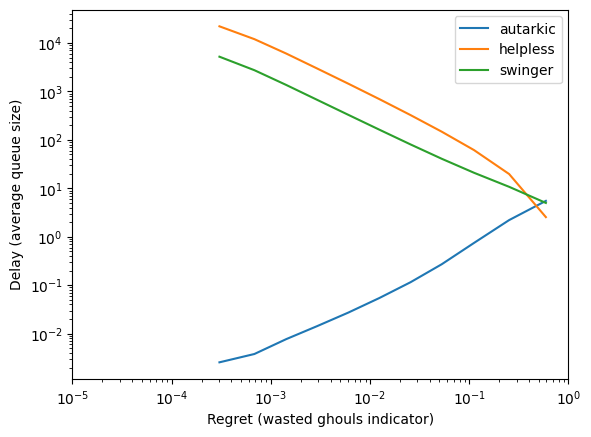

In [35]:
from matplotlib import pyplot as plt

r = res['discarding']
x = r['regret']
ys = r['grouped_delay']
for l in ys[0].keys():
    y = [yy[l] for yy in ys]
    plt.loglog(x, y, label=l)
plt.xlabel('Regret (wasted ghouls indicator)')
plt.ylabel('Delay (average queue size)')
plt.xlim([.00001, 1])
plt.legend()
import tikzplotlib
tikzplotlib.save("waste.tex")
plt.show()

### Humans

We now incoporate some amount of *humans* (vampire-free pre-ghouls) into the mix.

In [36]:
def mix_model(α = .001):
    μc = arrival_rates(vgs)
    μd = arrival_rates(humans)
    μ = [(1-α)*p/np.sum(μc) for p in μc]+[α*p/np.sum(μd) for p in μd]
    model = build_model(vgs+humans)
    model.rates = μ
    return model

:::note
If we try to numerically compute the minimum proportion of humans that allows the system to be stable, one gets a positive value. This is due to the numerical margin of error of the best positive position. For highly skewed problem, it can be difficult to distinguish a zeroed edge from a barely positive one.

Yet, the value found has its one interest: it gives us a bound below which stability may be difficult to observe.
:::

In [37]:
def find_threshold(steps=20):
    u = 1.0
    l = 0.0
    for _ in range(steps):
        c = (u+l)/2
        m = mix_model(c)
        if m.stabilizable:
            u = c
        else:
            l = c
    return (u+l)/2
find_threshold()

0.0004916191101074219

In [38]:
base_params['simulator'] = 'virtual_queue'
xp = sm.XP('humanities', iterator=sm.Iterator('model', [2**i*.0005 for i in range(11)], 'alpha', lambda a: mix_model(a)), **base_params)

In [39]:
import multiprocess as mp
with mp.Pool() as p:
    res = sm.evaluate(xp, [grouped_delay], pool=p)

  0%|          | 0/11 [00:00<?, ?it/s]

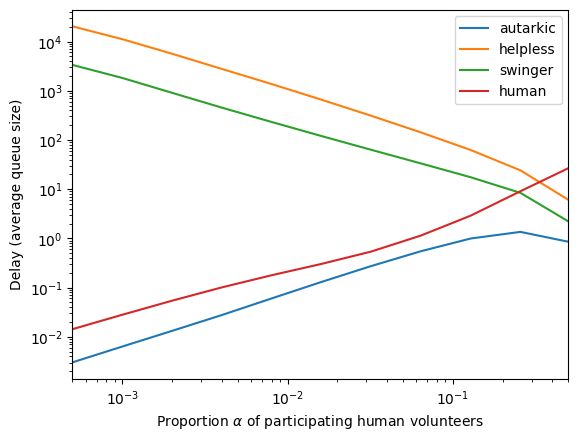

In [40]:
r = res['humanities']
x = r['alpha']
ys = r['grouped_delay']
for l in ys[0].keys():
    y = [e[l] for e in ys]
    plt.loglog(x, y, label=l)
plt.xlabel('Proportion $\\alpha$ of participating human volunteers')
plt.ylabel('Delay (average queue size)')
plt.xlim([.0005, .5])
plt.legend()
import tikzplotlib
tikzplotlib.save("humans.tex")
plt.show()